In [1]:
import sys
from pathlib import Path
import pandas as pd

# Repo root (works if cwd is project root or refined_tables/)
for _p in (Path.cwd(), *Path.cwd().parents):
    if (_p / "pyproject.toml").exists():
        sys.path.insert(0, str(_p))
        break

from injestion.core.bq import get_client
from injestion.core.env import load_env
from injestion.sportradar import SportradarManager

load_env()

client = get_client()
_rankings_table = SportradarManager().get_table_id("rankings")


In [2]:
def get_rankings_data() -> pd.DataFrame:
    _rankings_table = SportradarManager().get_table_id("rankings")
    query = f"""
    SELECT *
    FROM `{_rankings_table}`
    WHERE generated_at = (SELECT MAX(generated_at) FROM `{_rankings_table}`)
    ORDER BY ranking_name, rank
    """
    return client.query(query).to_dataframe()

rankings_latest = get_rankings_data()


In [3]:
womens_rankings = rankings_latest[rankings_latest["gender"] == "women"].reset_index(drop=True)
mens_rankings = rankings_latest[rankings_latest["gender"] == "men"].reset_index(drop=True)

<Axes: >

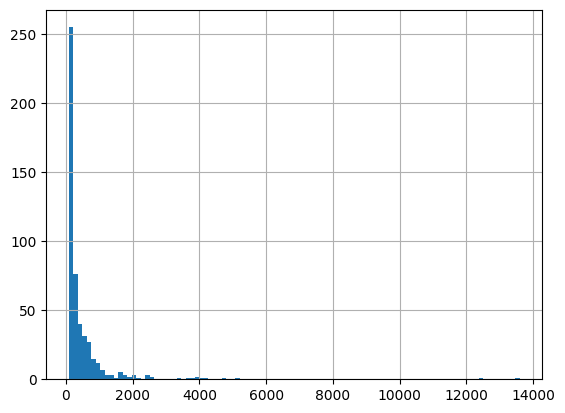

In [4]:
mens_rankings['points'].hist(bins=100)

In [5]:
from refined_tables.elo import (
    EloInitConfig,
    build_initial_elo_table,
    elo_init_for_competitor_id,
    lookup_points_by_competitor_id,
    points_for_competitor_id,
    sample_unranked_elo_init,
)

# Slim input: name, id, points (works for any gender / list you pass in)
mens_slim = mens_rankings[["competitor_name", "competitor_id", "points"]].copy()

elo_cfg = EloInitConfig(
    elo_init_min=30.0,
    elo_init_max=90.0,
    shrink_lambda=0.65,
    shrink_mu="median",
    random_seed=42,
)

mens_elo_init = build_initial_elo_table(mens_slim, config=elo_cfg)

# Intermediate columns for plots: p_lo_used, p_hi_used, points_score_u, elo_raw, shrink_mu_used, elo_after_shrink, elo_init
mens_elo_init[["competitor_name", "points", "points_score_u", "elo_raw", "elo_after_shrink", "elo_init"]].head(12)

,competitor_name,points,points_score_u,elo_raw,elo_after_shrink,elo_init
0,"Alcaraz, Carlos",13590,1.000000,90.000000,72.810297,72.810297
1,"Sinner, Jannik",12400,0.981901,88.914074,72.104445,72.104445
2,"Zverev, Alexander",5205,0.810462,78.627720,65.418314,65.418314
3,"Djokovic, Novak",4720,0.791146,77.468786,64.665007,64.665007
4,"Musetti, Lorenzo",4265,0.771129,76.267746,63.884332,63.884332
5,"de Minaur, Alex",4095,0.763097,75.785812,63.571074,63.571074
6,"Auger-Aliassime, Felix",4000,0.758462,75.507707,63.390306,63.390306
7,"Fritz, Taylor",3870,0.751937,75.116248,63.135858,63.135858
8,"Shelton, Ben",3860,0.751427,75.085593,63.115932,63.115932
9,"Medvedev, Daniil",3610,0.738204,74.292262,62.600267,62.600267


In [6]:
# Slim input: name, id, points (works for any gender / list you pass in)
womens_slim = womens_rankings[["competitor_name", "competitor_id", "points"]].copy()

elo_cfg = EloInitConfig(
    elo_init_min=30.0,
    elo_init_max=90.0,
    shrink_lambda=0.65,
    shrink_mu="median",
    random_seed=42,
)

womens_elo_init = build_initial_elo_table(womens_slim, config=elo_cfg)

# Intermediate columns for plots: p_lo_used, p_hi_used, points_score_u, elo_raw, shrink_mu_used, elo_after_shrink, elo_init
womens_elo_init[["competitor_name", "points", "points_score_u", "elo_raw", "elo_after_shrink", "elo_init"]].head(12)

,competitor_name,points,points_score_u,elo_raw,elo_after_shrink,elo_init
0,"Sabalenka, Aryna",11025,1.000000,90.000000,73.242963,73.242963
1,"Rybakina, Elena",8108,0.933573,86.014403,70.652325,70.652325
2,"Gauff, Coco",7278,0.910231,84.613834,69.741955,69.741955
3,"Swiatek, Iga",7263,0.909785,84.587078,69.724563,69.724563
4,"Pegula, Jessica",6243,0.877075,82.624516,68.448898,68.448898
5,"Anisimova, Amanda",6180,0.874883,82.492983,68.363401,68.363401
6,"Svitolina, Elina",3965,0.778961,76.737684,64.622457,64.622457
7,"Paolini, Jasmine",3907,0.775777,76.546599,64.498252,64.498252
8,"Mboko, Victoria",3531,0.753908,75.234483,63.645377,63.645377
9,"Andreeva, Mirra",3121,0.727234,73.634047,62.605093,62.605093


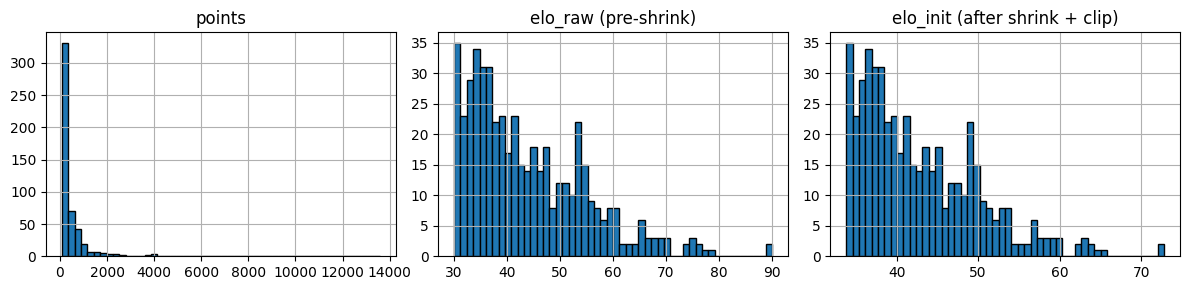

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
mens_elo_init["points"].hist(bins=50, ax=axes[0], edgecolor="black")
axes[0].set_title("points")
mens_elo_init["elo_raw"].hist(bins=50, ax=axes[1], edgecolor="black")
axes[1].set_title("elo_raw (pre-shrink)")
mens_elo_init["elo_init"].hist(bins=50, ax=axes[2], edgecolor="black")
axes[2].set_title("elo_init (after shrink + clip)")
plt.tight_layout()
plt.show()

In [8]:
# Lookup by competitor_id: ranked vs unranked random prior
examples = [
    ("sr:competitor:407573", "Alcaraz"),  # top of snapshot
    ("sr:competitor:225050", "Sinner"),
    ("sr:competitor:000000000", "not in table"),
]
for cid, label in examples:
    pts = points_for_competitor_id(cid, mens_slim)
    elo, src = elo_init_for_competitor_id(cid, mens_elo_init, config=elo_cfg)
    print(f"{label!r} ({cid}): points={pts}, elo_init={elo:.2f} ({src})")

rng = elo_cfg.make_rng()
print("unranked samples:", [round(sample_unranked_elo_init(elo_cfg, rng), 2) for _ in range(5)])

'Alcaraz' (sr:competitor:407573): points=13590.0, elo_init=72.81 (ranked)
'Sinner' (sr:competitor:225050): points=12400.0, elo_init=72.10 (ranked)
'not in table' (sr:competitor:000000000): points=None, elo_init=25.91 (unranked)
unranked samples: [25.91, 21.88, 27.25, 27.82, 19.15]


In [9]:
def get_competitors_data() -> pd.DataFrame:
    event_summary_table_id = SportradarManager().get_table_id("event_summary")
    query = f"""
    SELECT DISTINCT competitor_name, competitor_id, gender
    FROM (
    SELECT 
        home_competitor_name AS competitor_name,
        home_competitor_id as competitor_id,
        competition_gender as gender
    FROM `{event_summary_table_id}`
    WHERE competition_type = 'singles'
    UNION ALL
    SELECT 
        away_competitor_name AS competitor_name, 
        away_competitor_id as competitor_id,
        competition_gender as gender
    FROM `{event_summary_table_id}`
    WHERE competition_type = 'singles'
    )
    """
    return client.query(query).to_dataframe()

competitors = get_competitors_data()


In [10]:
competitors.head()

,competitor_name,competitor_id,gender
0,"Nava, Emilio",sr:competitor:284805,men
1,"Kovalik, Jozef",sr:competitor:57021,men
2,"Medjedovic, Hamad",sr:competitor:601146,men
3,"Nagal, Sumit",sr:competitor:131566,men
4,"Gabashvili, Teymuraz",sr:competitor:14823,men


In [11]:
mens_rankings.head()

,generated_at,ranking_name,gender,year,week,competitor_id,rank,movement,points,competitions_played,competitor_name,country,country_code,abbreviation
0,2026-04-01 10:28:55+00:00,ATP,men,2026,14,sr:competitor:407573,1,0,13590,18,"Alcaraz, Carlos",Spain,ESP,ALC
1,2026-04-01 10:28:55+00:00,ATP,men,2026,14,sr:competitor:225050,2,0,12400,19,"Sinner, Jannik",Italy,ITA,SIN
2,2026-04-01 10:28:55+00:00,ATP,men,2026,14,sr:competitor:57163,3,1,5205,22,"Zverev, Alexander",Germany,DEU,ZVE
3,2026-04-01 10:28:55+00:00,ATP,men,2026,14,sr:competitor:14882,4,-1,4720,18,"Djokovic, Novak",Serbia,SRB,DJO
4,2026-04-01 10:28:55+00:00,ATP,men,2026,14,sr:competitor:359602,5,0,4265,22,"Musetti, Lorenzo",Italy,ITA,MUS
